In [ ]:
# PHASE 1: Data Loading, Exploration & Visualisation
# ============================================================================
# This notebook explores the structural health monitoring dataset for the
# Hohenzollernbrücke project. We load all simulation cases, extract labels
# from folder names, examine the raw data format, and visualise key patterns.
#
# Before any ML model, we need to understand:
#   - How many cases do we have, and how are they distributed across labels?
#   - What does the raw data look like (scale, shape, distributions)?
#   - Are there visible differences between perfect and imperfect cases?
# ============================================================================

import numpy as np
import pandas as pd
print(f"NumPy: {np.__version__}, Pandas: {pd.__version__}")
print("Environment is ready!")

NumPy: 2.4.4, Pandas: 3.0.2
Environment is ready!


In [ ]:
# Set up project paths
# ============================================================================
# The notebook runs from the /notebooks folder, so we move one level up to
# the project root. All paths are then relative to the project root.
# This only needs to run once per kernel session.

os.chdir(os.path.join(os.getcwd(), ".."))
print(f"Working directory: {os.getcwd()}")

import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set the base path to your data folder
BASE_DIR = Path("data")
PERFECT_DIR = BASE_DIR / "perfect_structure_data"
IMPERFECT_DIR = BASE_DIR / "imperfect_structure_data"
TEST_DIR = BASE_DIR / "test_set"

# Quick check: list what's inside
print("Perfect cases:")
for folder in sorted(PERFECT_DIR.iterdir()):
    print(f"  {folder.name}")

print(f"\nImperfect cases:")
for folder in sorted(IMPERFECT_DIR.iterdir()):
    print(f"  {folder.name}")

print(f"\nTest set contents:")
for item in sorted(TEST_DIR.iterdir()):
    print(f"  {item.name}")

Working directory: c:\Users\Vishal Prabu\Desktop\genai-projects\structural-health-monitoring
Perfect cases:
  Perfect_structure_1_train_extreme_rack_5000N
  Perfect_structure_1_train_extreme_track_2000N
  Perfect_structure_1_train_middle_track_2000N
  Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N

Imperfect cases:
  Imperfect_no_1_1_train_extreme_track_2000N
  Imperfect_no_1_1_train_extreme_track_5000N
  Imperfect_no_1_2_trains_opposite_direction_extreme_track_2000N
  Imperfect_no_2_1_train_extreme_track_2000N
  imperfect_no_2_1_train_extreme_Track_5000N
  Imperfect_no_2_2_trains_opposite_direction_Extreme_tracks_2000N
  Imperfect_no_3_1_train_extreme_track_2000N
  imperfect_no_3_1_train_extreme_track_5000N
  Imperfect_no_3_2_trains_opposite_direction_extreme_tracks_2000N
  imperfect_no_4_1_train_extreme_track_2000N
  imperfect_no_4_1_train_extreme_track_5000N
  Imperfect_no_4_2_trains_opposite_direction_extreme_tracks_2000N
  imperfect_no_5_1_train_extreme_track_2

In [ ]:
# Parse folder names into structured metadata
# ============================================================================
# Each folder name encodes the full simulation configuration:
#   - Condition: perfect or imperfect
#   - Imperfection location: 1-5 (only for imperfect cases)
#   - Number of trains: 1 or 2
#   - Track position: extreme, middle, or opposite_direction
#   - Applied load: 2000N or 5000N
#
# The naming is inconsistent (mixed casing, "rack" vs "track", etc.)
# so we use case-insensitive regex to handle all variations.
# ============================================================================

def parse_folder_name(name):
    """Extract structured metadata from a simulation folder name."""
    lower = name.lower()
    info = {"folder_name": name}
    
    # Condition & imperfection number
    if "imperfect" in lower:
        info["condition"] = "imperfect"
        match = re.search(r"imperfect_no_(\d+)", lower)
        info["imperfection_no"] = int(match.group(1)) if match else None
    else:
        info["condition"] = "perfect"
        info["imperfection_no"] = None
    
    # Number of trains
    info["num_trains"] = 2 if "2_trains" in lower else 1
    
    # Track position
    if "opposite_direction" in lower:
        info["track_position"] = "opposite_direction"
    elif "middle" in lower:
        info["track_position"] = "middle"
    elif "extreme" in lower:
        info["track_position"] = "extreme"
    else:
        info["track_position"] = "unknown"
    
    # Load magnitude (look for a number followed by N)
    match = re.search(r"(\d+)N", name, re.IGNORECASE)
    info["load_N"] = int(match.group(1)) if match else None
    
    # Classification label
    if info["condition"] == "perfect":
        info["label"] = "perfect"
    else:
        info["label"] = f"imperfect_{info['imperfection_no']}"
    
    return info

# Parse all cases
records = []
for folder in sorted(PERFECT_DIR.iterdir()):
    records.append({**parse_folder_name(folder.name), "source": "perfect_structure_data"})

for folder in sorted(IMPERFECT_DIR.iterdir()):
    records.append({**parse_folder_name(folder.name), "source": "imperfect_structure_data"})

for folder in sorted(TEST_DIR.iterdir()):
    records.append({**parse_folder_name(folder.name), "source": "test_set"})

# Build the table
df_cases = pd.DataFrame(records)
cols = ["folder_name", "source", "condition", "imperfection_no", "num_trains", 
        "track_position", "load_N", "label"]
df_cases = df_cases[cols]

print(f"Total cases: {len(df_cases)}")
print(f"  Training (perfect): {len(df_cases[df_cases['label'] == 'perfect'])}")
print(f"  Training (imperfect): {len(df_cases[df_cases['condition'] == 'imperfect']) - 1}")
print(f"  Test: 1")
print(f"\nLabel distribution:")
print(df_cases["label"].value_counts().sort_index().to_string())
print(f"\n{df_cases.to_string(index=False)}")

Total cases: 20
  Training (perfect): 4
  Training (imperfect): 15
  Test: 1

Label distribution:
label
imperfect_1    3
imperfect_2    3
imperfect_3    3
imperfect_4    4
imperfect_5    3
perfect        4

                                                       folder_name                   source condition  imperfection_no  num_trains     track_position  load_N       label
                      Perfect_structure_1_train_extreme_rack_5000N   perfect_structure_data   perfect              NaN           1            extreme    5000     perfect
                     Perfect_structure_1_train_extreme_track_2000N   perfect_structure_data   perfect              NaN           1            extreme    2000     perfect
                      Perfect_structure_1_train_middle_track_2000N   perfect_structure_data   perfect              NaN           1             middle    2000     perfect
Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N   perfect_structure_data   perfect            

In [ ]:
# Load and examine a single CSV file
# ============================================================================
# Before processing all 140 files (20 cases × 7 files each), load one file
# to understand the exact format: column names, data types, row count, and
# any quirks (e.g., trailing commas creating empty columns).
#
# Using the first perfect case as the reference since the perfect structure
# has the full node set (no removed members).
# ============================================================================

sample_folder = PERFECT_DIR / "Perfect_structure_1_train_extreme_track_2000N"
sample_file = sample_folder / "Deformation_X_axis.csv"

df_sample = pd.read_csv(sample_file)

print(f"File: {sample_file.name}")
print(f"Shape (raw): {df_sample.shape}")
print(f"\nColumn names:")
for i, col in enumerate(df_sample.columns):
    print(f"  [{i}] {col}")

print(f"\nFirst 3 rows:")
print(df_sample.head(3).to_string(index=False))

print(f"\nLast 3 rows:")
print(df_sample.tail(3).to_string(index=False))

print(f"\nData types:")
print(df_sample.dtypes.to_string())

File: Deformation_X_axis.csv
Shape (raw): (29226, 13)

Column names:
  [0] Node Number
  [1] Directional Deformation (mm) for X_axis
  [2] Directional Deformation (mm) for X_axis 0.1
  [3] Directional Deformation (mm) for X_axis 0.5
  [4] Directional Deformation (mm) for X_axis 0.9
  [5] Directional Deformation (mm) for X_axis 1.1
  [6] Directional Deformation (mm) for X_axis 1.5
  [7] Directional Deformation (mm) for X_axis 1.9
  [8] Directional Deformation (mm) for X_axis 2.1
  [9] Directional Deformation (mm) for X_axis 2.5
  [10] Directional Deformation (mm) for X_axis 2.9
  [11] Directional Deformation (mm) for X_axis 3
  [12] Unnamed: 12

First 3 rows:
 Node Number  Directional Deformation (mm) for X_axis  Directional Deformation (mm) for X_axis 0.1  Directional Deformation (mm) for X_axis 0.5  Directional Deformation (mm) for X_axis 0.9  Directional Deformation (mm) for X_axis 1.1  Directional Deformation (mm) for X_axis 1.5  Directional Deformation (mm) for X_axis 1.9  Directio

In [17]:
# Reusable data loading function
# ============================================================================
# Each simulation case (folder) contains 7 CSV files. This function loads
# all 7 files from a given folder and returns them in a clean format:
#   - Drops the trailing NaN column (caused by trailing commas in the CSV)
#   - Renames columns from verbose ANSYS headers to short, consistent names
#     using the format: t_0.0, t_0.1, t_0.5, ... t_3.0
#   - Sets the Node Number as the DataFrame index for easy node-level lookups
#   - Returns a dictionary keyed by quantity name (e.g., "deform_x", "stress_xy")
#
# The 7 physical quantities are:
#   Deformations:  X, Y, Z directions + Total magnitude
#   Shear stresses: XY, XZ, YZ planes
#
# Output structure:
#   load_case(folder) returns a dict with 7 keys:
#   {
#       "deform_x":     DataFrame (29226 rows × 11 cols),
#       "deform_y":     DataFrame (29226 rows × 11 cols),
#       "deform_z":     DataFrame (29226 rows × 11 cols),
#       "deform_total": DataFrame (29226 rows × 11 cols),
#       "stress_xy":    DataFrame (29226 rows × 11 cols),
#       "stress_xz":    DataFrame (29226 rows × 11 cols),
#       "stress_yz":    DataFrame (29226 rows × 11 cols),
#   }
#
#   Each DataFrame looks like:
#                   t_0.0     t_0.1     t_0.5  ...  t_2.9     t_3.0
#   node_number
#   1           -0.000004  0.000248  0.000487  ...  0.000569 -0.000004
#   2           -0.000004  0.000265  0.000521  ...  0.000485 -0.000004
#   ...
#   29226       -0.000001  0.011684  0.023400  ... -0.068284 -0.000001
#
#   Note: imperfect cases have fewer rows (~28,900) since removing a
#   structural member removes the associated nodes from the FEA mesh.
# ============================================================================

# The 7 CSV files and their short names
FILE_MAP = {
    "Deformation_X_axis.csv":  "deform_x",
    "Deformation_Y_axis.csv":  "deform_y",
    "Deformation_Z_axis.csv":  "deform_z",
    "Total Deformation.csv":   "deform_total",
    "Shear Stress XY.csv":     "stress_xy",
    "Shear Stress XZ.csv":     "stress_xz",
    "Shear Stress YZ.csv":     "stress_yz",
}

# Time steps extracted from the column headers
TIME_STEPS = [0.0, 0.1, 0.5, 0.9, 1.1, 1.5, 1.9, 2.1, 2.5, 2.9, 3.0]
TIME_COLS = [f"t_{t}" for t in TIME_STEPS]

def load_case(folder_path):
    """
    Load all 7 CSV files from a simulation case folder.
    
    Returns a dict: {"deform_x": DataFrame, "deform_y": DataFrame, ...}
    Each DataFrame has Node Number as index and columns t_0.0 through t_3.0.
    """
    data = {}
    folder_path = Path(folder_path)
    
    for filename, short_name in FILE_MAP.items():
        filepath = folder_path / filename
        
        if not filepath.exists():
            print(f"  WARNING: {filename} not found in {folder_path.name}")
            continue
        
        df = pd.read_csv(filepath)
        
        # Drop the trailing NaN column
        if df.columns[-1].startswith("Unnamed"):
            df = df.iloc[:, :-1]
        
        # Rename columns: first col is node number, rest are time steps
        df.columns = ["node_number"] + TIME_COLS
        df = df.set_index("node_number")
        
        data[short_name] = df
    
    return data

# Test the loader on one case
test_data = load_case(sample_folder)
print(f"Loaded {len(test_data)} quantities from: {sample_folder.name}")
print(f"\nQuantities: {list(test_data.keys())}")
print(f"Nodes: {test_data['deform_x'].shape[0]}")
print(f"Time steps: {test_data['deform_x'].shape[1]}")
print(f"\nSample (deform_x, first 3 nodes):")
print(test_data["deform_x"].head(3).to_string())

Loaded 7 quantities from: Perfect_structure_1_train_extreme_track_2000N

Quantities: ['deform_x', 'deform_y', 'deform_z', 'deform_total', 'stress_xy', 'stress_xz', 'stress_yz']
Nodes: 29226
Time steps: 11

Sample (deform_x, first 3 nodes):
                t_0.0     t_0.1     t_0.5     t_0.9     t_1.1     t_1.5     t_1.9     t_2.1     t_2.5     t_2.9     t_3.0
node_number                                                                                                              
1           -0.000004  0.000248  0.000487  0.000248  0.000688  0.001307  0.000687  0.000571 -0.000519  0.000569 -0.000004
2           -0.000004  0.000265  0.000521  0.000265  0.000690  0.001310  0.000690  0.000487 -0.000686  0.000485 -0.000004
3           -0.000004  0.000282  0.000555  0.000282  0.000690  0.001310  0.000690  0.000368 -0.000925  0.000365 -0.000004


In [16]:
# Load all 20 simulation cases and compute summary statistics
# ============================================================================
# For each case, load all 7 CSV files and compute basic statistics across
# all nodes at each time step: mean, std, min, max, and RMS.
#
# This serves two purposes:
#   1. Verify that all files load correctly (no missing/corrupt data)
#   2. Get a first look at whether perfect vs imperfect cases show
#      different statistical signatures — if they do, even simple
#      features may be enough for classification.
#
# The results are stored in a list of dicts for easy conversion to a
# DataFrame. Each row = one case, with summary stats as columns.
# ============================================================================

def get_case_folder(row):
    """Given a row from df_cases, return the full path to the case folder."""
    if row["source"] == "perfect_structure_data":
        return PERFECT_DIR / row["folder_name"]
    elif row["source"] == "imperfect_structure_data":
        return IMPERFECT_DIR / row["folder_name"]
    else:
        return TEST_DIR / row["folder_name"]

summary_records = []

for idx, row in df_cases.iterrows():
    folder = get_case_folder(row)
    case_data = load_case(folder)
    
    record = {
        "folder_name": row["folder_name"],
        "label": row["label"],
        "condition": row["condition"],
        "imperfection_no": row["imperfection_no"],
        "load_N": row["load_N"],
        "track_position": row["track_position"],
    }
    
    # Node count — differs between perfect and imperfect cases
    record["node_count"] = case_data["deform_x"].shape[0]
    
    # Compute stats for each quantity across all nodes and time steps
    for qty_name, df_qty in case_data.items():
        values = df_qty.values  # shape: (n_nodes, 11)
        record[f"{qty_name}_mean"] = np.mean(values)
        record[f"{qty_name}_std"] = np.std(values)
        record[f"{qty_name}_absmax"] = np.max(np.abs(values))
        record[f"{qty_name}_rms"] = np.sqrt(np.mean(values ** 2))
    
    summary_records.append(record)
    print(f"  Loaded: {row['folder_name']} ({record['node_count']} nodes)")

df_summary = pd.DataFrame(summary_records)
print(f"\nAll {len(df_summary)} cases loaded successfully.")
print(f"\nNode counts by condition:")
print(df_summary.groupby("label")["node_count"].apply(list).to_string())

  Loaded: Perfect_structure_1_train_extreme_rack_5000N (29226 nodes)
  Loaded: Perfect_structure_1_train_extreme_track_2000N (29226 nodes)
  Loaded: Perfect_structure_1_train_middle_track_2000N (29226 nodes)
  Loaded: Perfect_structure_2_trains_opposite_direction_extreme_tracks_2000N (29226 nodes)
  Loaded: Imperfect_no_1_1_train_extreme_track_2000N (28902 nodes)
  Loaded: Imperfect_no_1_1_train_extreme_track_5000N (28902 nodes)
  Loaded: Imperfect_no_1_2_trains_opposite_direction_extreme_track_2000N (28902 nodes)
  Loaded: Imperfect_no_2_1_train_extreme_track_2000N (28794 nodes)
  Loaded: imperfect_no_2_1_train_extreme_Track_5000N (28794 nodes)
  Loaded: Imperfect_no_2_2_trains_opposite_direction_Extreme_tracks_2000N (28794 nodes)
  Loaded: Imperfect_no_3_1_train_extreme_track_2000N (28212 nodes)
  Loaded: imperfect_no_3_1_train_extreme_track_5000N (28212 nodes)
  Loaded: Imperfect_no_3_2_trains_opposite_direction_extreme_tracks_2000N (28212 nodes)
  Loaded: imperfect_no_4_1_train_ext

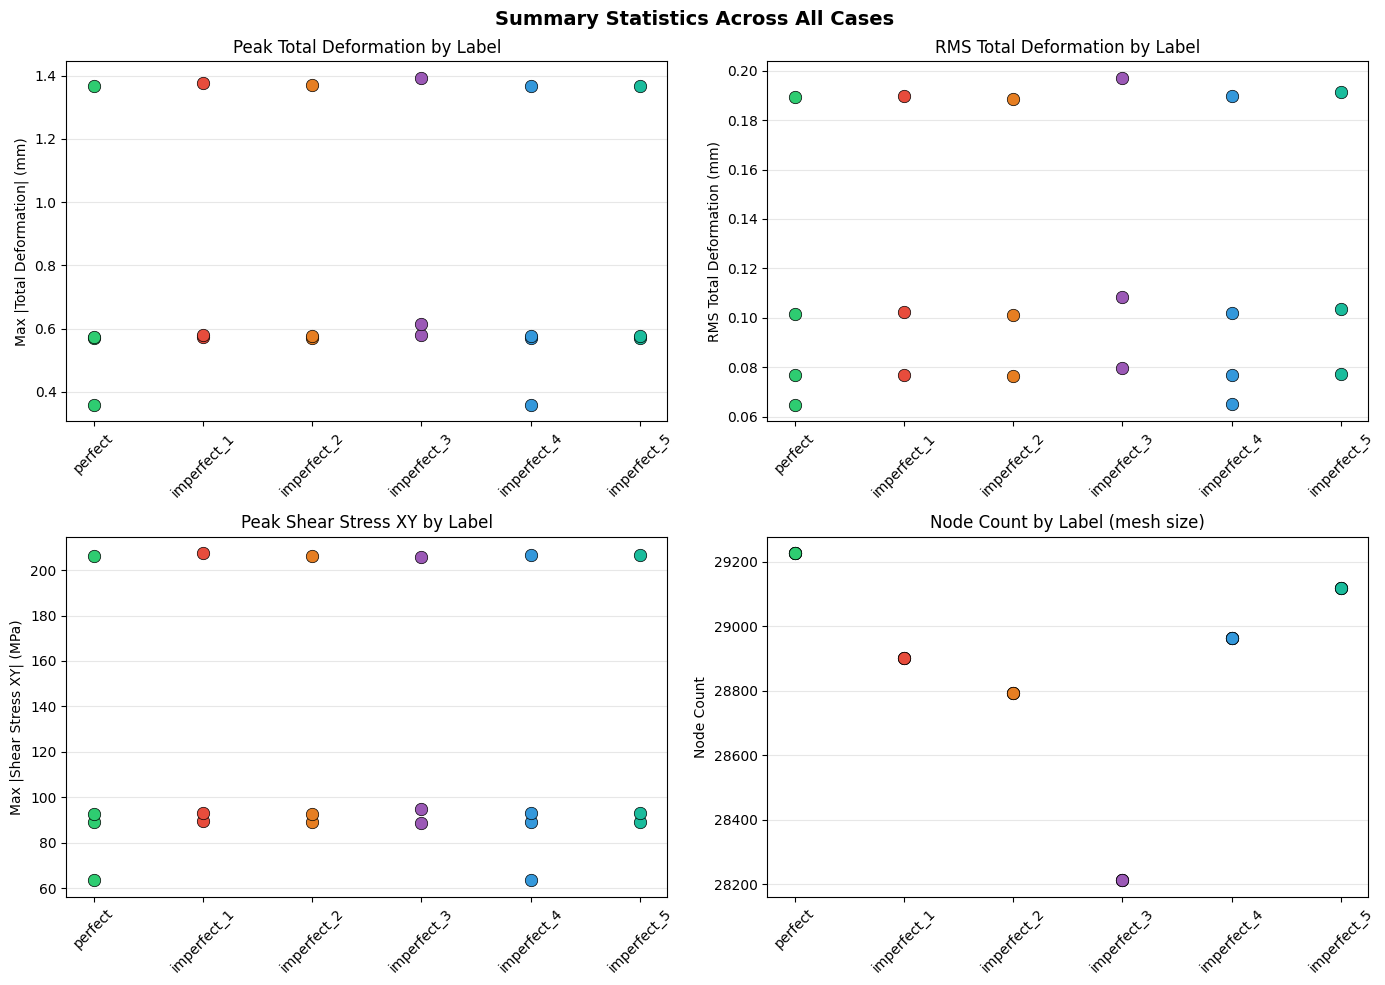

Figure saved to results/01_summary_statistics.png


In [ ]:
# Visualise summary statistics: perfect vs imperfect comparison
# ============================================================================
# Plot the key summary statistics (absolute max deformation, RMS stress)
# across all cases, colored by label. This is the first visual check for
# whether perfect and imperfect cases are distinguishable from aggregate
# numbers alone.
# Each dot in these plots represents ONE simulation case (one folder).
# The statistic for each dot is computed by flattening the entire data
# matrix (all ~29,000 nodes × 11 time steps ≈ 320,000 values) into a
# single number:
# If the dots cluster by color, simple features may suffice for
# classification. If they overlap heavily, more sophisticated feature
# engineering will be needed.
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Summary Statistics Across All Cases - All time steps", fontsize=14, fontweight="bold")

# Color map for labels
palette = {
    "perfect": "#2ecc71",
    "imperfect_1": "#e74c3c",
    "imperfect_2": "#e67e22",
    "imperfect_3": "#9b59b6",
    "imperfect_4": "#3498db",
    "imperfect_5": "#1abc9c",
}

# Exclude test case for cleaner training-only view
df_train = df_summary[df_summary["label"] != "imperfect_4"].copy()
df_test_row = df_summary[df_summary["folder_name"].str.contains("middle_track")].copy()
df_plot = df_summary.copy()

# Plot 1: Max absolute total deformation
ax = axes[0, 0]
for label, color in palette.items():
    mask = df_plot["label"] == label
    ax.scatter(df_plot.loc[mask, "label"], df_plot.loc[mask, "deform_total_absmax"],
               c=color, s=80, edgecolors="black", linewidth=0.5, label=label, zorder=3)
ax.set_ylabel("Max |Total Deformation| (mm)")
ax.set_title("Peak Total Deformation by Label")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

# Plot 2: RMS of total deformation
ax = axes[0, 1]
for label, color in palette.items():
    mask = df_plot["label"] == label
    ax.scatter(df_plot.loc[mask, "label"], df_plot.loc[mask, "deform_total_rms"],
               c=color, s=80, edgecolors="black", linewidth=0.5, zorder=3)
ax.set_ylabel("RMS Total Deformation (mm)")
ax.set_title("RMS Total Deformation by Label")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

# Plot 3: Max absolute shear stress XY
ax = axes[1, 0]
for label, color in palette.items():
    mask = df_plot["label"] == label
    ax.scatter(df_plot.loc[mask, "label"], df_plot.loc[mask, "stress_xy_absmax"],
               c=color, s=80, edgecolors="black", linewidth=0.5, zorder=3)
ax.set_ylabel("Max |Shear Stress XY| (MPa)")
ax.set_title("Peak Shear Stress XY by Label")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

# Plot 4: Node count (confirms structural difference)
ax = axes[1, 1]
for label, color in palette.items():
    mask = df_plot["label"] == label
    ax.scatter(df_plot.loc[mask, "label"], df_plot.loc[mask, "node_count"],
               c=color, s=80, edgecolors="black", linewidth=0.5, zorder=3)
ax.set_ylabel("Node Count")
ax.set_title("Node Count by Label (mesh size)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/01_summary_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/01_summary_statistics.png")

Matched cases (6):
                                  folder_name       label
Perfect_structure_1_train_extreme_track_2000N     perfect
   Imperfect_no_1_1_train_extreme_track_2000N imperfect_1
   Imperfect_no_2_1_train_extreme_track_2000N imperfect_2
   Imperfect_no_3_1_train_extreme_track_2000N imperfect_3
   imperfect_no_4_1_train_extreme_track_2000N imperfect_4
   imperfect_no_5_1_train_extreme_track_2000N imperfect_5


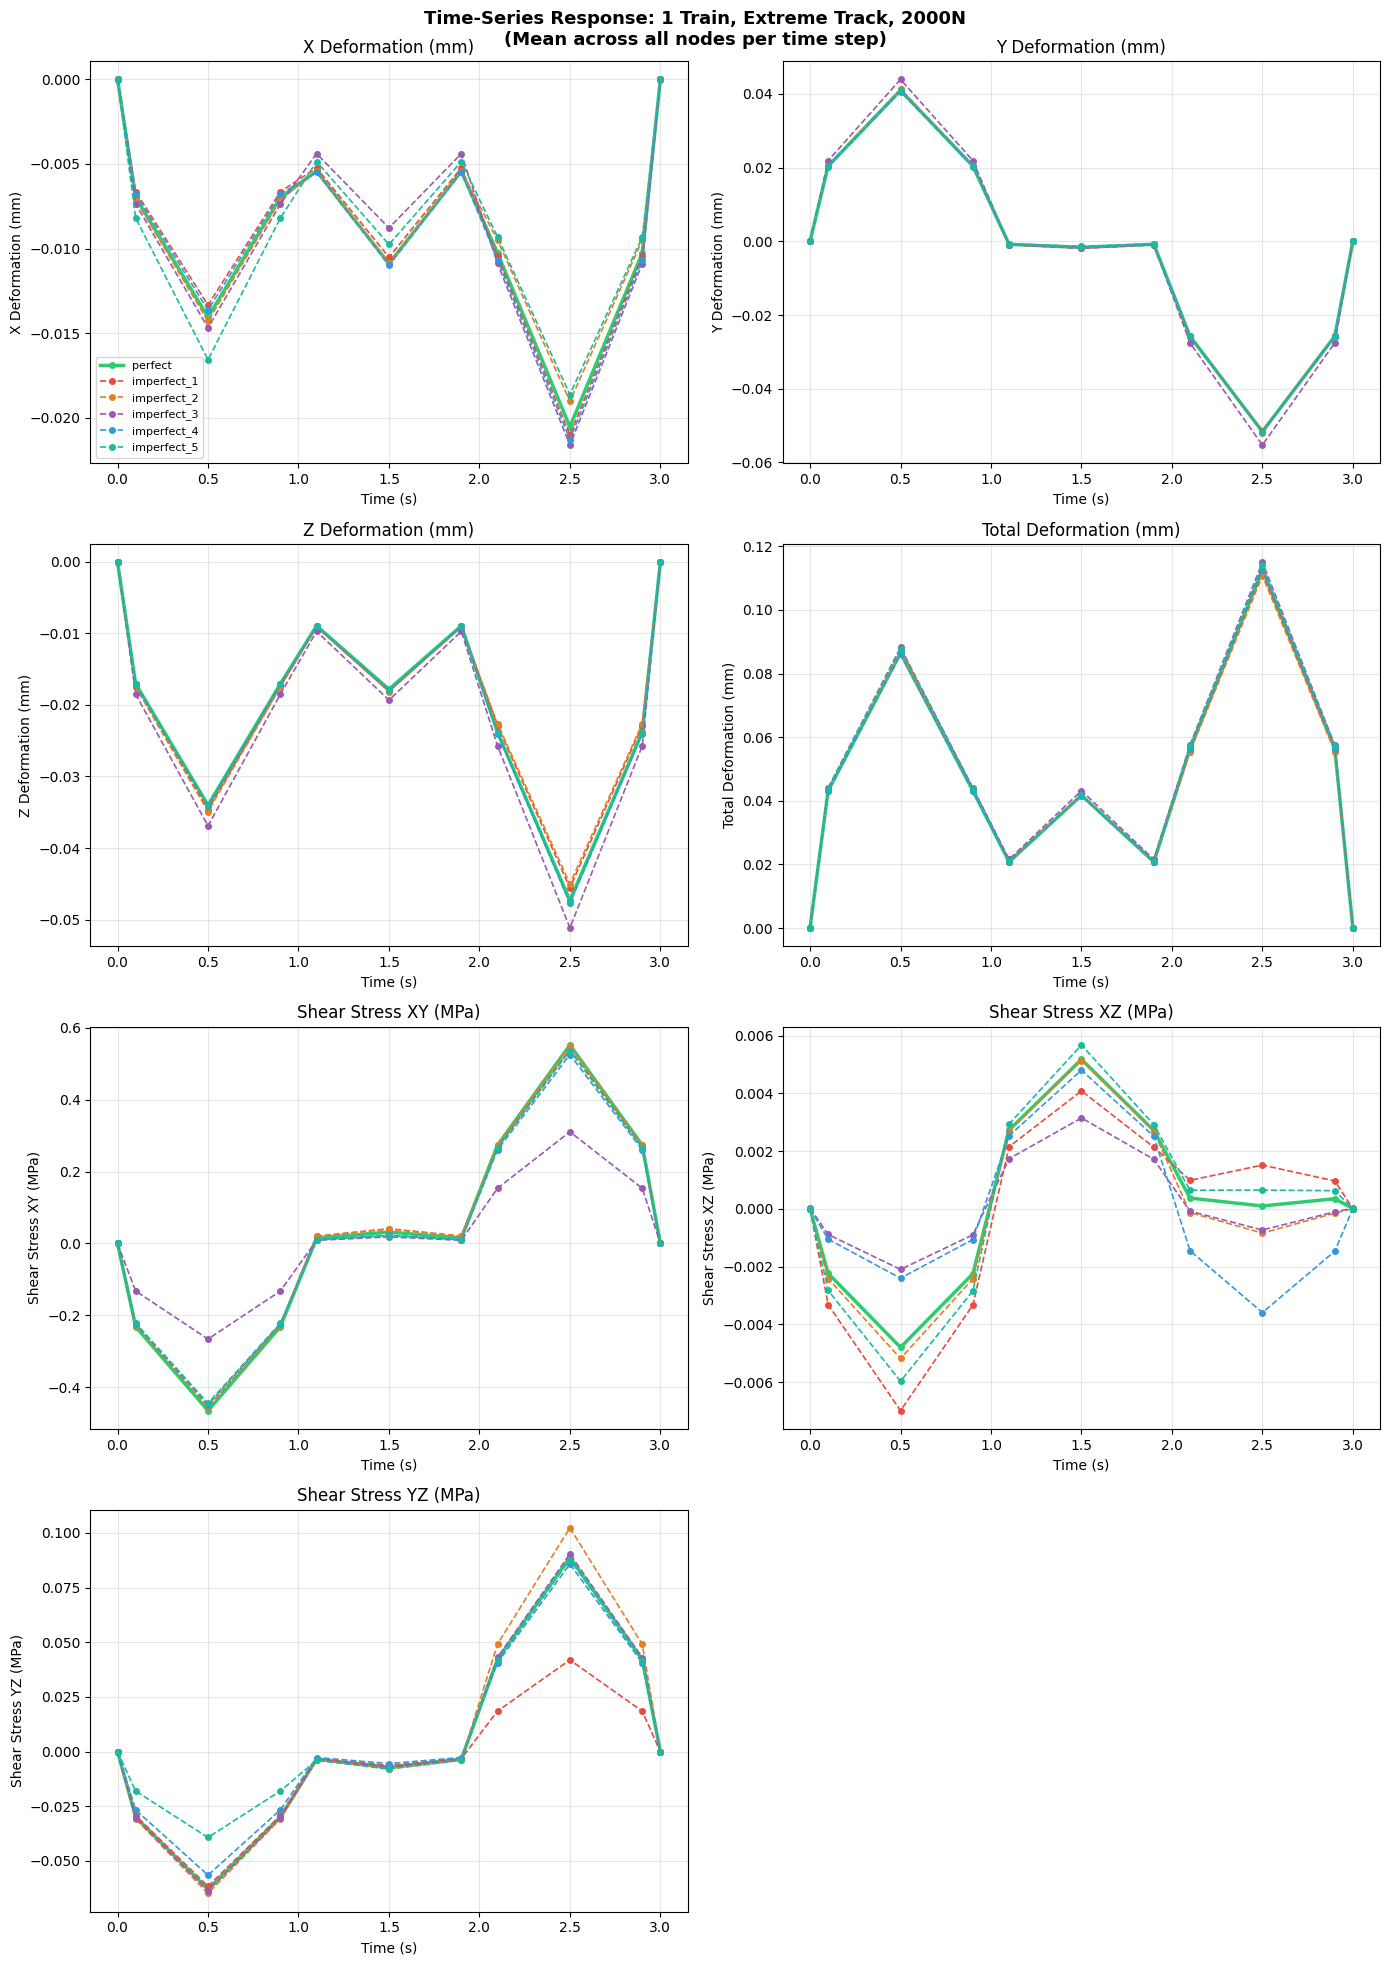

Figure saved to results/02_timeseries_matched_comparison.png


In [ ]:
# Time-series comparison: perfect vs imperfect under same loading: 1 train, extreme track, 2000N
# ============================================================================
# To see how damage affects the structural response, the comparison must
# be done under identical loading conditions. Otherwise differences in
# load magnitude or train position dominate over damage effects.
#
# Here, the loading condition "1 train, extreme track, 2000N" is selected
# because it exists for ALL labels (perfect + all 5 imperfections).
#
# For each case, the mean total deformation across all nodes is computed
# at each of the 11 time steps, producing one time-series curve per case.
#
# The three loading phases are visible in the temporal pattern (Referring to the ANSYS setup load distribution):
#   Phase A (0.0–0.9s): Train at position B (left span)
#   Phase B (1.1–1.9s): Train at position C (middle span)
#   Phase C (2.1–2.9s): Train at position D (right span)
#   t=0.0 and t=3.0:   Rest states (gravity only)
#
# If damage changes the structural response, the curves will diverge
# from the perfect baseline — especially during the loading phase
# where the train is nearest to the damaged member.
# ============================================================================

# Filter cases: 1 train, extreme track, 2000N only
matched_cases = df_cases[
    (df_cases["num_trains"] == 1) &
    (df_cases["track_position"] == "extreme") &
    (df_cases["load_N"] == 2000)
].copy()

print(f"Matched cases ({len(matched_cases)}):")
print(matched_cases[["folder_name", "label"]].to_string(index=False))

# Labels for each quantity
qty_labels = {
    "deform_x":     "X Deformation (mm)",
    "deform_y":     "Y Deformation (mm)",
    "deform_z":     "Z Deformation (mm)",
    "deform_total": "Total Deformation (mm)",
    "stress_xy":    "Shear Stress XY (MPa)",
    "stress_xz":    "Shear Stress XZ (MPa)",
    "stress_yz":    "Shear Stress YZ (MPa)",
}

palette = {
    "perfect": "#2ecc71",
    "imperfect_1": "#e74c3c",
    "imperfect_2": "#e67e22",
    "imperfect_3": "#9b59b6",
    "imperfect_4": "#3498db",
    "imperfect_5": "#1abc9c",
}

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes_flat = axes.flatten()
fig.suptitle("Time-Series Response: 1 Train, Extreme Track, 2000N\n(Mean across all nodes per time step)",
             fontsize=13, fontweight="bold")

# Load each matched case and plot all 7 quantities
for _, row in matched_cases.iterrows():
    folder = get_case_folder(row)
    case_data = load_case(folder)
    label = row["label"]
    color = palette[label]
    lw = 2.5 if label == "perfect" else 1.2
    ls = "-" if label == "perfect" else "--"
    
    for i, (qty_name, ylabel) in enumerate(qty_labels.items()):
        mean_per_timestep = case_data[qty_name].mean(axis=0).values
        axes_flat[i].plot(TIME_STEPS, mean_per_timestep, color=color, linewidth=lw,
                          linestyle=ls, marker="o", markersize=4, label=label)

# Set labels and formatting for each subplot
for i, (qty_name, ylabel) in enumerate(qty_labels.items()):
    axes_flat[i].set_ylabel(ylabel)
    axes_flat[i].set_xlabel("Time (s)")
    axes_flat[i].set_title(ylabel)
    axes_flat[i].grid(alpha=0.3)

# Add legend to first subplot only
axes_flat[0].legend(fontsize=8, loc="best")

# Hide the empty 8th subplot (7 quantities, 8 subplot slots)
axes_flat[7].set_visible(False)

plt.tight_layout()
plt.savefig("results/02_timeseries_matched_2000N_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/02_timeseries_matched_comparison.png")

Matched cases (6):
                                 folder_name       label
Perfect_structure_1_train_extreme_rack_5000N     perfect
  Imperfect_no_1_1_train_extreme_track_5000N imperfect_1
  imperfect_no_2_1_train_extreme_Track_5000N imperfect_2
  imperfect_no_3_1_train_extreme_track_5000N imperfect_3
  imperfect_no_4_1_train_extreme_track_5000N imperfect_4
  imperfect_no_5_1_train_extreme_track_5000N imperfect_5


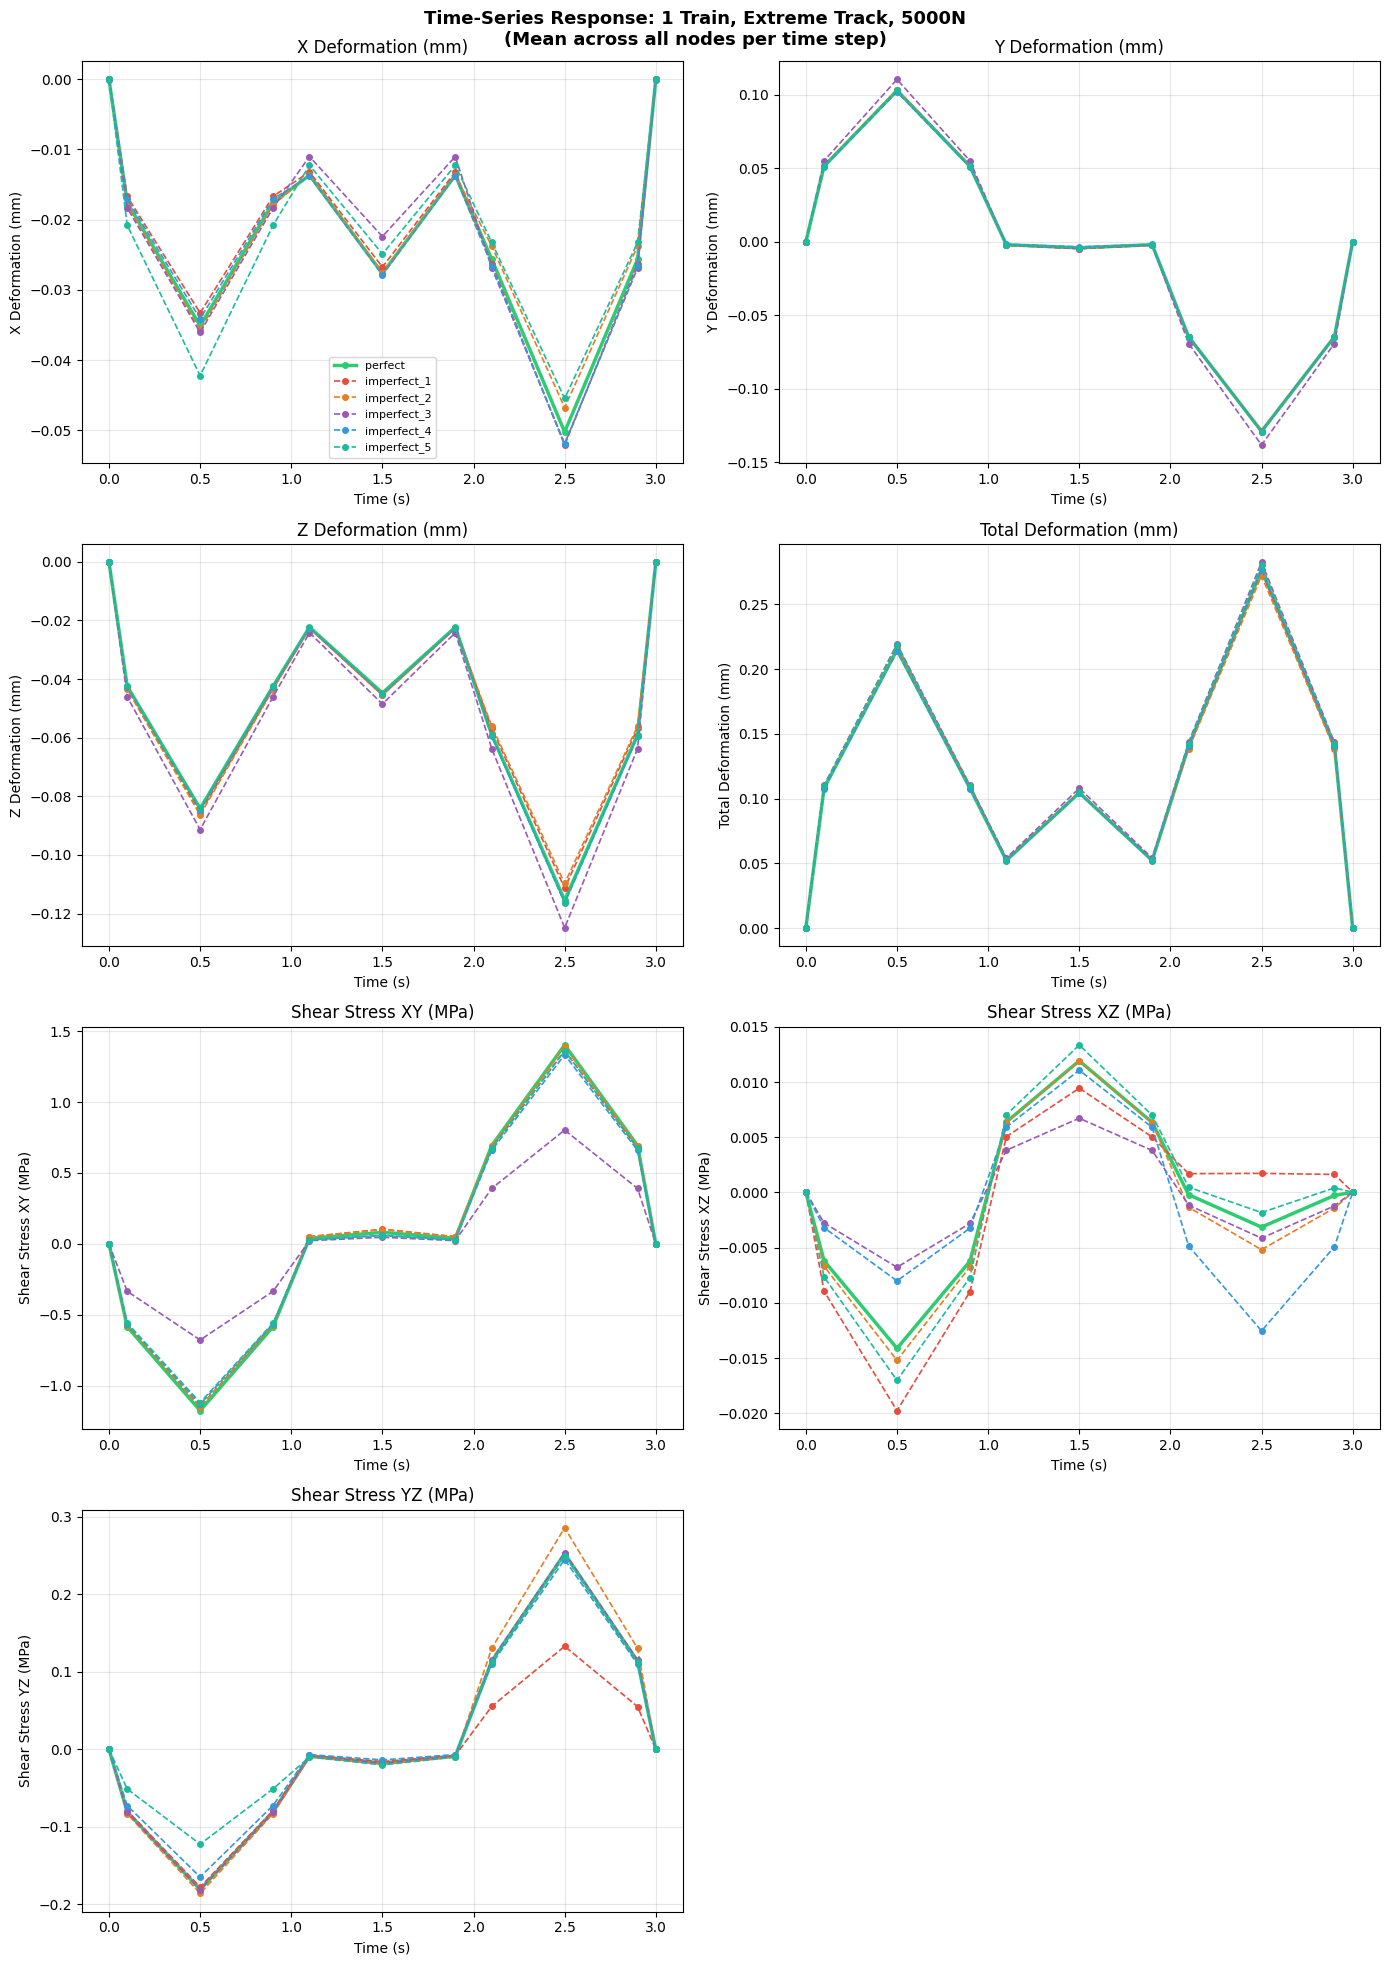

Figure saved to results/03_timeseries_5000N_comparison.png


In [ ]:
# Time-series comparison: perfect vs imperfect under same loading: 1 train, extreme track, 5000N
# ============================================================================
# Same analysis as Cell 8 but for the 5000N loading condition.
# Higher loads amplify deformations and stresses, so damage effects
# may be more or less visible depending on whether the signal-to-noise
# ratio improves with load magnitude.
# ============================================================================

matched_5000 = df_cases[
    (df_cases["num_trains"] == 1) &
    (df_cases["track_position"] == "extreme") &
    (df_cases["load_N"] == 5000)
].copy()

print(f"Matched cases ({len(matched_5000)}):")
print(matched_5000[["folder_name", "label"]].to_string(index=False))

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes_flat = axes.flatten()
fig.suptitle("Time-Series Response: 1 Train, Extreme Track, 5000N\n(Mean across all nodes per time step)",
             fontsize=13, fontweight="bold")

for _, row in matched_5000.iterrows():
    folder = get_case_folder(row)
    case_data = load_case(folder)
    label = row["label"]
    color = palette[label]
    lw = 2.5 if label == "perfect" else 1.2
    ls = "-" if label == "perfect" else "--"
    
    for i, (qty_name, ylabel) in enumerate(qty_labels.items()):
        mean_per_timestep = case_data[qty_name].mean(axis=0).values
        axes_flat[i].plot(TIME_STEPS, mean_per_timestep, color=color, linewidth=lw,
                          linestyle=ls, marker="o", markersize=4, label=label)

for i, (qty_name, ylabel) in enumerate(qty_labels.items()):
    axes_flat[i].set_ylabel(ylabel)
    axes_flat[i].set_xlabel("Time (s)")
    axes_flat[i].set_title(ylabel)
    axes_flat[i].grid(alpha=0.3)

axes_flat[0].legend(fontsize=8, loc="best")
axes_flat[7].set_visible(False)

plt.tight_layout()
plt.savefig("results/03_timeseries_matched_5000N_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/03_timeseries_matched_5000N_comparison.png")

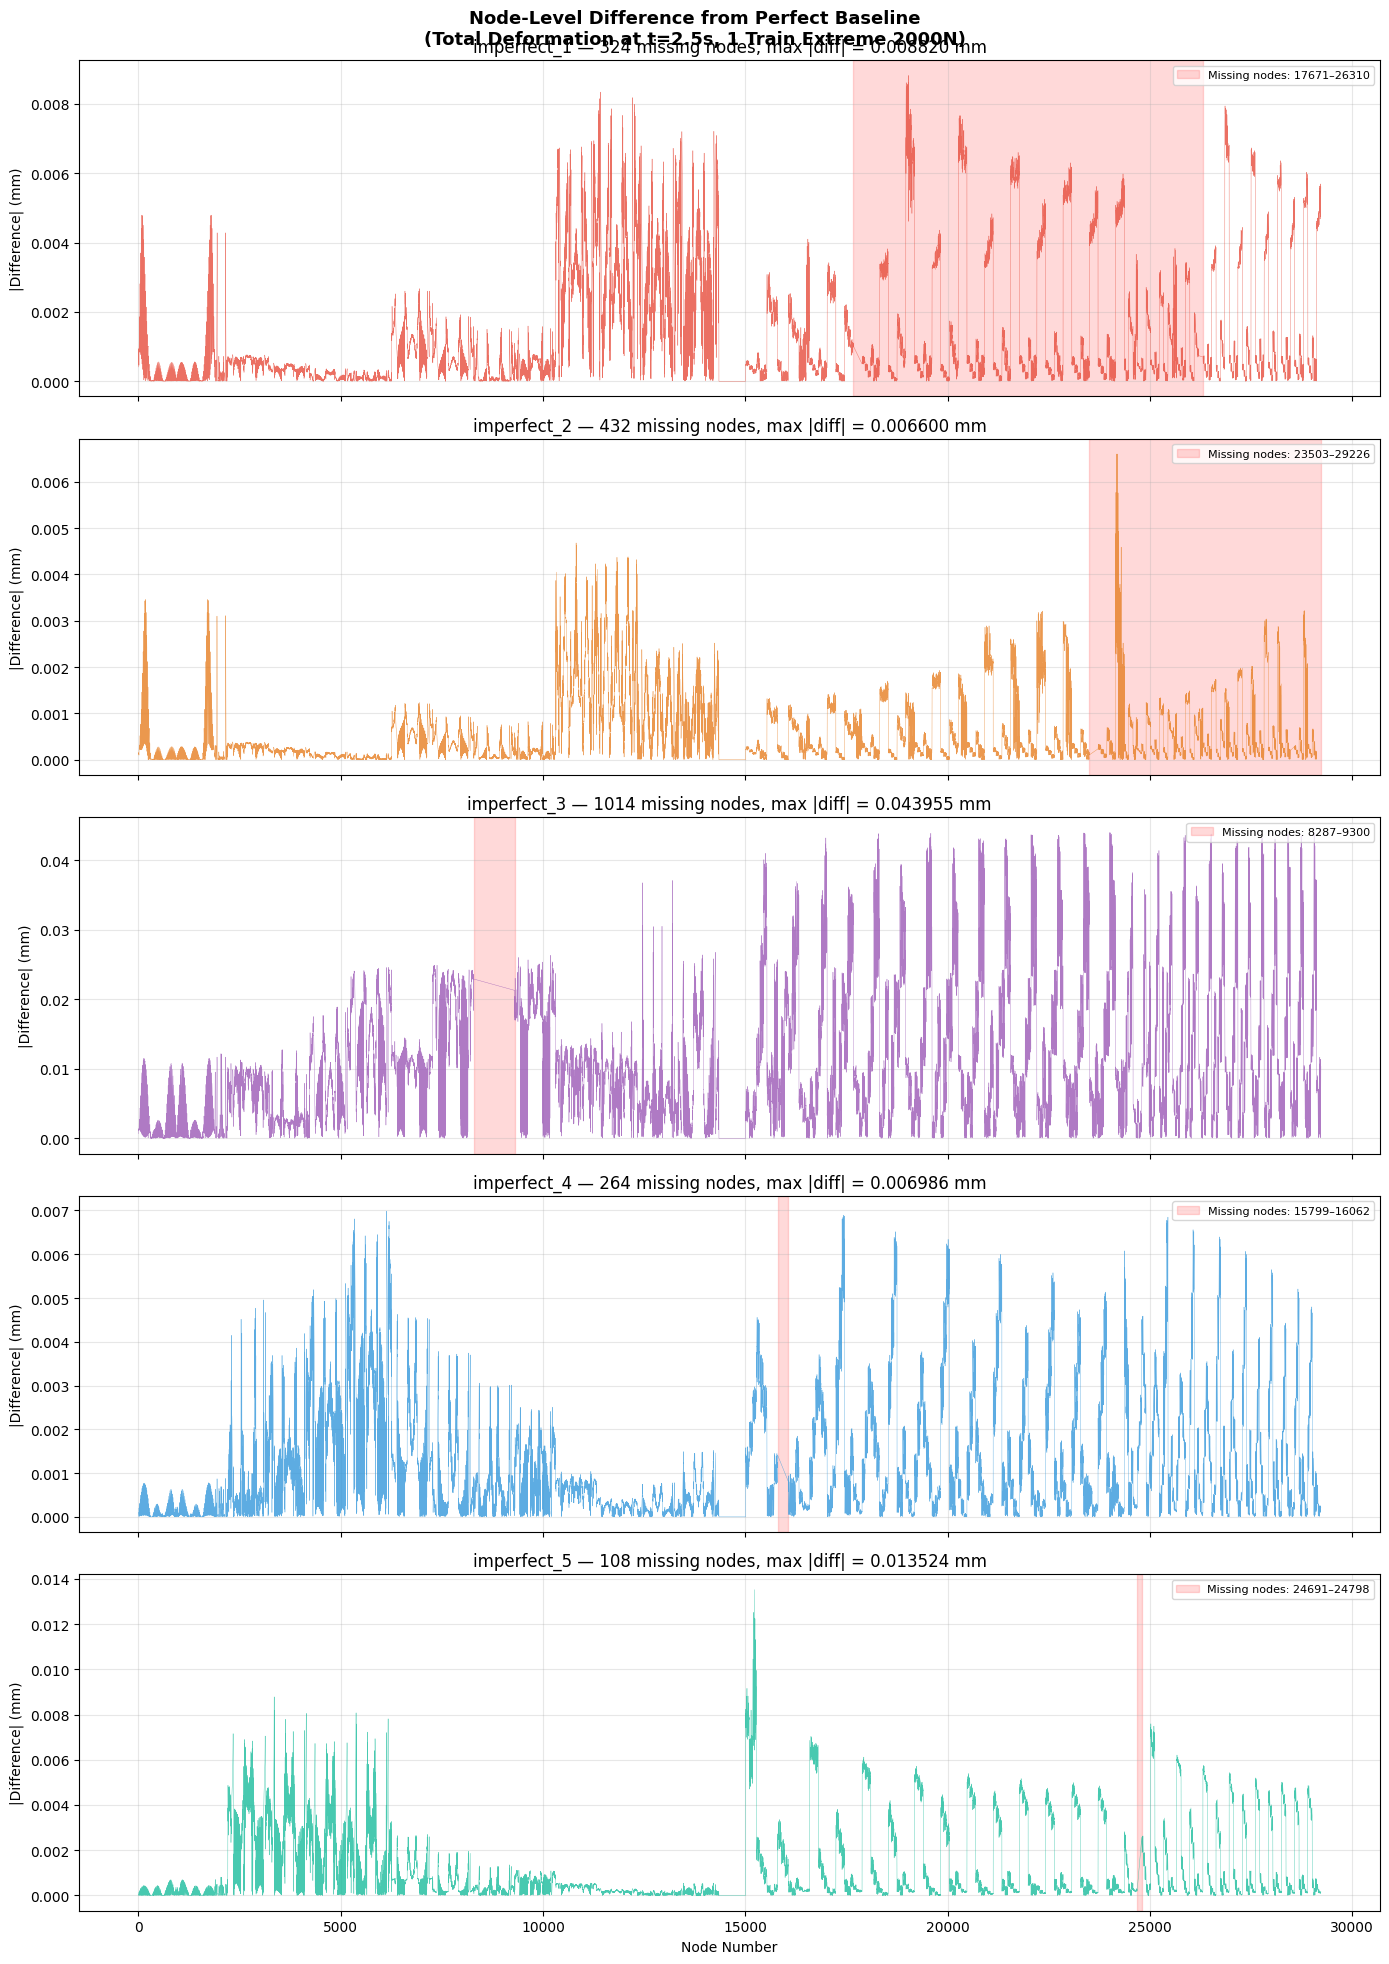

Figure saved to results/04_node_level_differences_2_5s.png


In [32]:
# Node-level damage localisation: baseline differencing
# ============================================================================
# The core idea behind damage localisation in SHM is comparing a
# potentially damaged structure's response against a known healthy
# (perfect) baseline under the same loading conditions.
#
# For each node that exists in both the perfect and imperfect case:
#   difference = imperfect_response - perfect_response
#
# If the structure is undamaged, this difference is zero everywhere.
# If damaged, the difference will be largest near the damage location
# because damage disrupts load paths locally — nodes far from damage
# are barely affected.
#
# Additionally, nodes that exist in the perfect case but are MISSING
# in the imperfect case are the removed structural member itself.
# In a real-world scenario sensors wouldn't reveal missing nodes
# directly, but the response-based difference approach would still
# highlight the damage region through abnormal neighbour responses.
#
# Here, the total deformation at t=2.5s (the time step with largest
# overall response from earlier analysis) is used for a clear signal.
# The loading condition is 1 train, extreme track, 2000N.
# ============================================================================
"""
Time step 2.5 chosen since from the previous graphs, it had the biggest reponse delta. 
Another option is 0.5
"""
# Load the perfect baseline
perfect_folder = PERFECT_DIR / "Perfect_structure_1_train_extreme_track_2000N"
perfect_data = load_case(perfect_folder)
perfect_total = perfect_data["deform_total"]["t_2.5"]

# Compare each imperfect case against the perfect baseline
imperfect_2000N = df_cases[
    (df_cases["condition"] == "imperfect") &
    (df_cases["num_trains"] == 1) &
    (df_cases["track_position"] == "extreme") &
    (df_cases["load_N"] == 2000)
].copy()

fig, axes = plt.subplots(5, 1, figsize=(14, 20), sharex=True)
fig.suptitle("Node-Level Difference from Perfect Baseline\n(Total Deformation at t=2.5s, 1 Train Extreme 2000N)",
             fontsize=13, fontweight="bold")
fig.subplots_adjust(top=1)

for idx, (_, row) in enumerate(imperfect_2000N.iterrows()):
    folder = get_case_folder(row)
    imp_data = load_case(folder)
    imp_total = imp_data["deform_total"]["t_2.5"]
    
    # Find common nodes (present in both perfect and imperfect)
    common_nodes = perfect_total.index.intersection(imp_total.index)
    
    # Find missing nodes (in perfect but not in imperfect = removed member)
    missing_nodes = perfect_total.index.difference(imp_total.index)
    
    # Compute difference at common nodes
    diff = imp_total.loc[common_nodes] - perfect_total.loc[common_nodes]
    
    ax = axes[idx]
    ax.plot(diff.index, diff.abs().values, linewidth=0.3, color=palette[row["label"]], alpha=0.8)
    ax.set_ylabel("|Difference| (mm)")
    ax.set_title(f"{row['label']} — {len(missing_nodes)} missing nodes, "
                 f"max |diff| = {diff.abs().max():.6f} mm")
    ax.grid(alpha=0.3)
    
    # Mark the range of missing nodes with a red shaded region
    if len(missing_nodes) > 0:
        ax.axvspan(missing_nodes.min(), missing_nodes.max(),
                   alpha=0.15, color="red", label=f"Missing nodes: {missing_nodes.min()}–{missing_nodes.max()}")
        ax.legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Node Number")

plt.tight_layout()
plt.savefig("results/04_node_level_differences_2_5s.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/04_node_level_differences_2_5s.png")

## Phase 1: Key Observations

**Dataset Structure:**
- 20 total cases: 4 perfect, 15 imperfect (5 locations × 3 loading conditions), 1 test set
- Each case contains 7 CSV files (3 directional deformations, 1 total deformation, 3 shear stresses)
- Each CSV: ~29,000 nodes × 11 time steps (0.0s to 3.0s)
- Test set is labeled `Imperfect_no_4_1_train_middle_track_2000N` — serves as ground truth for validation

**Node Count by Imperfection:**
| Label | Node Count | Nodes Removed |
|-------|-----------|---------------|
| perfect | 29,226 | 0 |
| imperfect_1 | 28,902 | 324 |
| imperfect_2 | 28,794 | 432 |
| imperfect_3 | 28,212 | 1,014 |
| imperfect_4 | 28,962 | 264 |
| imperfect_5 | 29,118 | 108 |

**Time-Series Analysis (matched loading: 1 train, extreme, 2000N):**
- Global summary statistics (absmax, RMS across all nodes and time steps) are too coarse — labels overlap heavily
- Mean response per time step reveals visible separation between cases, especially in Y deformation, shear stress XZ, and shear stress YZ
- Imperfect_3 consistently shows the largest deviation — correlates with having the most nodes removed
- 2000N and 5000N loading conditions show similar separation patterns

**Node-Level Baseline Differencing:**
- Computed as: `difference = imperfect_response - perfect_response` at each common node
- Damage effect is NOT purely local — removing a member redistributes load paths globally, causing differences at nodes far from the damage site
- Max difference magnitudes: imperfect_3 (0.044 mm) >> imperfect_5 (0.014 mm) > imperfect_1 (0.009 mm) > imperfect_4 (0.007 mm) > imperfect_2 (0.007 mm)
- Implication for classification: the spatial *pattern* of differences across all nodes is the discriminating feature, not just peak location
- Implication for localisation: simple "find the max node" is insufficient; smarter spatial analysis needed